# Clasificador Multi-Clase

**Nombre:** 

**Carnet:** 

## Enunciado del Projecto https://llealgt.github.io/galileo_pia_applied_ml/proyecto/proyecto_clasificador_multiclase.html

## Elección del dataset

### Dataset Seleccionado: Wine Dataset (scikit-learn internal)

**Justificación de la elección:**
Para el desarrollo de este proyecto se ha seleccionado el dataset **Wine**, fundamentando la decisión en los siguientes criterios técnicos y metodológicos:

1. **Garantía de Foco en el Modelado:** Al ser mi primera experiencia práctica en Machine Learning, este dataset tabular puramente numérico y libre de valores faltantes (NaNs) me permite concentrar el 100% del esfuerzo académico en el núcleo del proyecto: el diseño sistemático de experimentos, el diagnóstico preciso de subajuste/sobreajuste (underfitting/overfitting) y la lógica de combinación en un modelo de ensamble.
2. **Cumplimiento Estricto de Requisitos:** Cuenta con 3 clases balanceadas en la variable objetivo, cumpliendo con la restricción de clasificación multi-clase sin añadir la complejidad matemática y de visualización que implicarían datasets de 6 o 7 clases (como HAR o Dry Bean).
3. **Eficiencia e Iteración Rápida:** Con 178 instancias y 13 características, la velocidad de cómputo es óptima. Esto me garantiza la viabilidad de ejecutar y registrar los 15 experimentos requeridos de forma ágil, permitiendo un análisis profundo del impacto de los hiperparámetros en las familias de Random Forest, XGBoost y Redes Neuronales sin comprometer los recursos de hardware.

## Dataset

### Importación del dataset

In [27]:
from sklearn.datasets import load_wine
from scipy import stats

wine = load_wine(as_frame=True)

### Carga y vista inicial del dataset

In [28]:
X = wine.data
y = wine.target

df = wine.frame
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


# Dataset Exploration

## Dimensiones del dataset

In [29]:
df.shape

(178, 14)

## Tipos de columnas

In [30]:
df.dtypes.value_counts()

float64    13
int64       1
Name: count, dtype: int64

In [31]:
numeric_columns = df.select_dtypes(include=['number']).columns.tolist()
numeric_columns

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline',
 'target']

In [32]:
categorical_columns = df.select_dtypes(include=['object', 'bool']).columns.tolist()
categorical_columns

[]

## Resumen estructural del dataset

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

## Estadísticas descriptivas

In [34]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


## Clases de la variable objetivo

In [35]:
wine.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

## Análisis de valores faltantes

In [36]:
missing_values = df.isna().sum()
missing_percentage = (missing_values / len(df) * 100).round(2)

missing_summary = missing_values.to_frame(name='valores_faltantes')
missing_summary['porcentaje_faltante'] = missing_percentage
missing_summary = missing_summary.sort_values(by='valores_faltantes', ascending=False)

missing_summary

,valores_faltantes,porcentaje_faltante
alcohol,0,0.0
malic_acid,0,0.0
ash,0,0.0
alcalinity_of_ash,0,0.0
magnesium,0,0.0
total_phenols,0,0.0
flavanoids,0,0.0
nonflavanoid_phenols,0,0.0
proanthocyanins,0,0.0
color_intensity,0,0.0


**Interpretación:** El dataset Wine no contiene valores faltantes en ninguna de sus columnas. Por lo tanto, no es necesario aplicar imputación, eliminación de registros ni tratamientos adicionales para datos nulos antes del modelado.

# Distribuciones

## Clases

class_0: 59 elementos
class_1: 71 elementos
class_2: 48 elementos


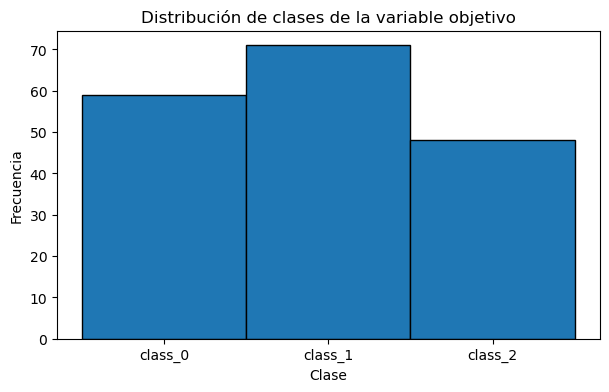

In [37]:
import matplotlib.pyplot as plt

class_counts = df['target'].value_counts().sort_index()

for class_id, count in class_counts.items():
    print(f'{wine.target_names[class_id]}: {count} elementos')

plt.figure(figsize=(7, 4))
plt.hist(df['target'], bins=[-0.5, 0.5, 1.5, 2.5], edgecolor='black')
plt.xticks([0, 1, 2], wine.target_names)
plt.title('Distribución de clases de la variable objetivo')
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.show()

**Conclusión:** Aunque la Clase 1 tiene mayor representación en el dataset y la Clase 2 cuenta con menos observaciones, la diferencia entre clases no es lo suficientemente grande como para considerarse un problema severo de desbalanceo. Por lo tanto, el dataset mantiene una distribución aceptable para continuar con el proceso de entrenamiento y evaluación de modelos de clasificación multi-clase.

## Distribución Variables Numéricas

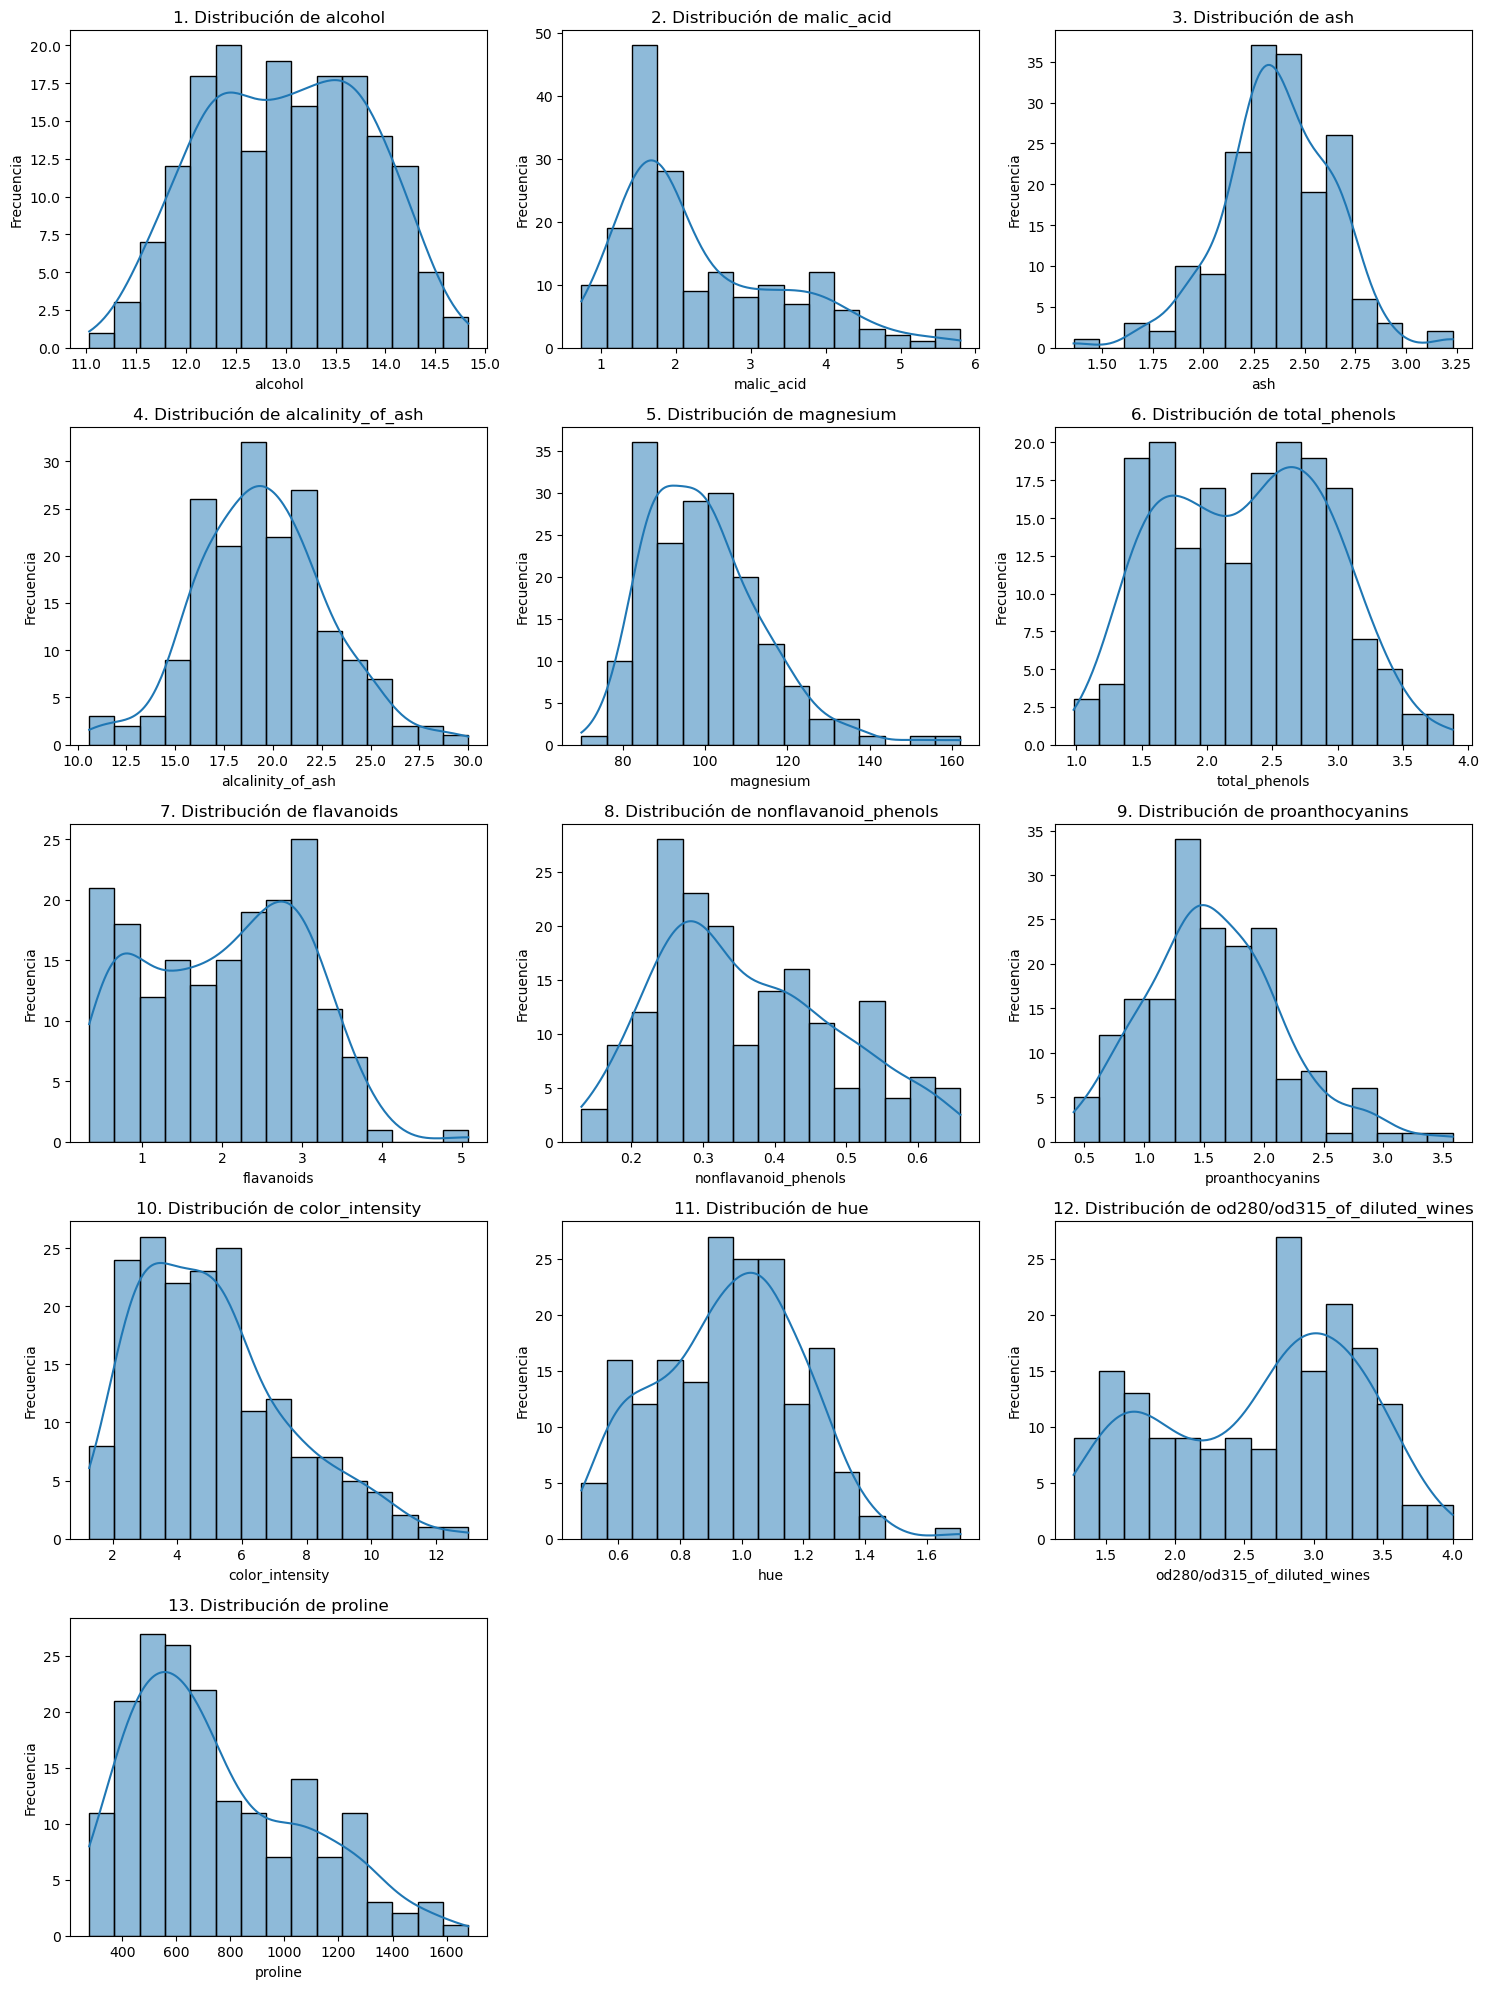

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_numeric_histograms(dataframe, columns, bins=15):
    n_cols = 3
    n_rows = (len(columns) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()

    for index, column in enumerate(columns):
        if column in dataframe.columns:
            sns.histplot(data=dataframe, x=column, bins=bins, kde=True, ax=axes[index])
        else:
            axes[index].text(0.5, 0.5, f'Columna {column} no encontrada', ha='center')
            axes[index].axis('off')
            continue

        axes[index].set_title(f'{index + 1}. Distribución de {column}')
        axes[index].set_xlabel(column)
        axes[index].set_ylabel('Frecuencia')

    for index in range(len(columns), len(axes)):
        axes[index].axis('off')

    plt.tight_layout()
    plt.show()

numeric_feature_columns = df.select_dtypes(include=['number']).columns.drop('target')
plot_numeric_histograms(df, numeric_feature_columns)

## Observaciones por variable

| Variable | Observación |
|---|---|
| `alcohol` | Distribución uniforme / normal ensanchada y simétrica. Indica niveles bien balanceados ($11\%$ - $15\%$) sin concentración en un solo extremo. |
| `malic_acid` | Distribución exponencial / en `L` con fuerte sesgo a la derecha (+). La mayoría de los vinos tiene acidez baja; hay pocos con valores muy altos (atípicos). |
| `ash` | Distribución normal (gaussiana) y simétrica. Muestra un comportamiento natural estándar centrado entre 2.3 y 2.4. |
| `alcalinity_of_ash` | Distribución normal (gaussiana) y simétrica. Es un comportamiento clásico y predecible, centrado alrededor de 20.5. |
| `magnesium` | Distribución unimodal con cola larga, sesgada a la derecha (+). Lo típico es encontrar valores entre 80 y 110, pero existen ejemplares inusualmente altos. |
| `total_phenols` | Distribución bimodal y simétrica a nivel global. Evidencia claramente que hay dos poblaciones o clases distintas de vino mezcladas en los datos. |
| `flavanoids` | Distribución bimodal con ligero sesgo. Es una excelente variable predictiva, ya que separa el dataset en dos grupos definidos. |
| `nonflavanoid_phenols` | Distribución unimodal irregular, sesgada a la derecha (+). Existe una alta concentración en valores bajos (0.2 - 0.3) con un descenso gradual. |
| `proanthocyanins` | Distribución unimodal en campana, ligeramente sesgada a la derecha (+). Los datos se concentran entre 1.0 y 2.0, con sutiles valores atípicos altos. |
| `color_intensity` | Distribución unimodal con cola larga, fuertemente sesgada a la derecha (+). La mayoría de los vinos tiene un color tenue/moderado, pero hay una cola de vinos muy oscuros. |
| `hue` | Distribución normal achatada, con un ligero sesgo a la izquierda (-). Centrada en 1.0, decae de forma más abrupta en su límite inferior. |
| `od280/od315_of_diluted_wines` | Distribución bimodal con sesgo a la izquierda (-). Es la tercera variable clave que confirma la separación clara de dos grupos. |
| `proline` | Distribución unimodal escalonada, fuertemente sesgada a la derecha (+). Dominan los valores bajos (400-700) y son muy pocos los vinos con concentraciones altas. |


# Deteccion de Anomalias

## Zscore

In [39]:
symetrical_cols = [
    'alcohol',
    'ash',
    'alcalinity_of_ash',
    'hue'
]

Anomalies found in 'alcohol': 0
Empty DataFrame
Columns: [alcohol, z_score_alcohol]
Index: []


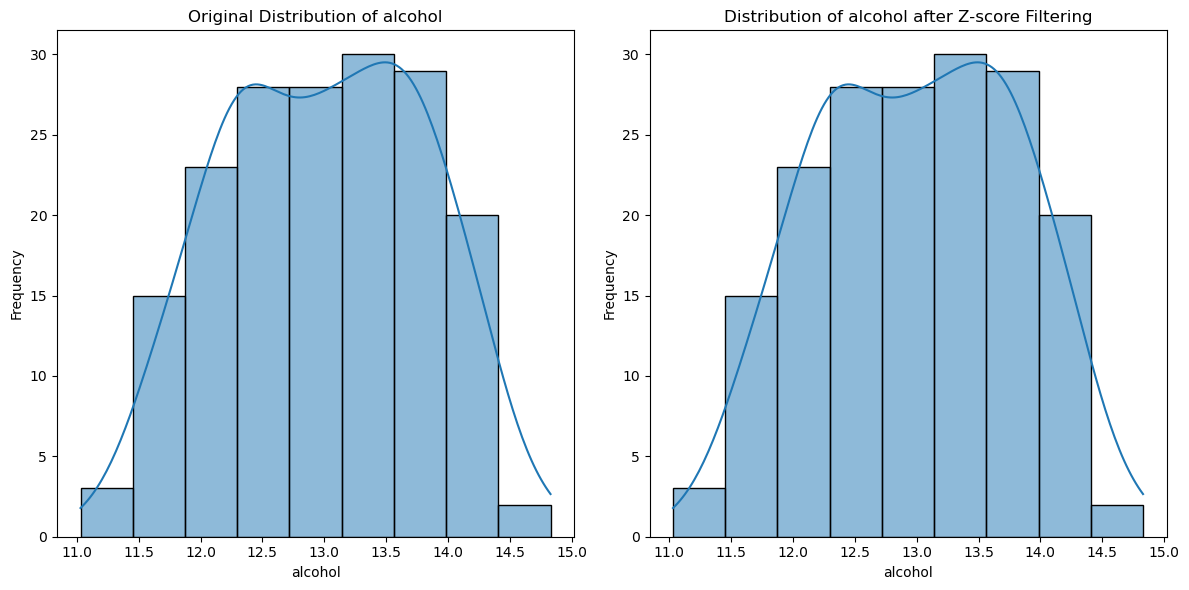

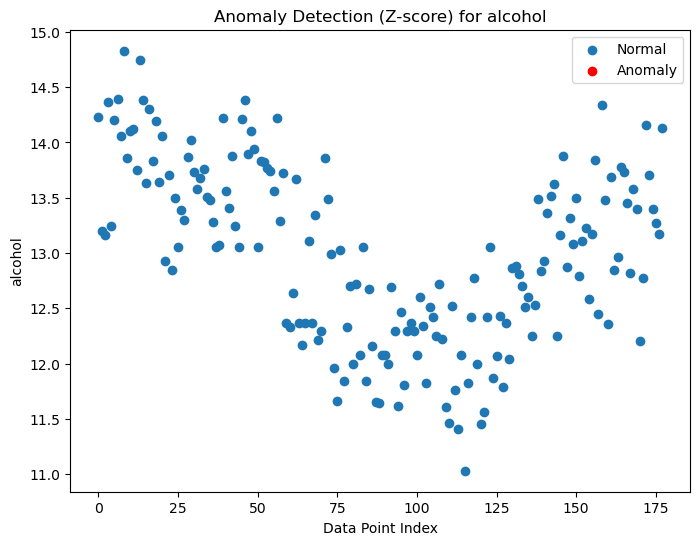

Anomalies found in 'ash': 3
      ash  z_score_ash
25   3.22     3.119772
59   1.36    -3.679162
121  3.23     3.156325


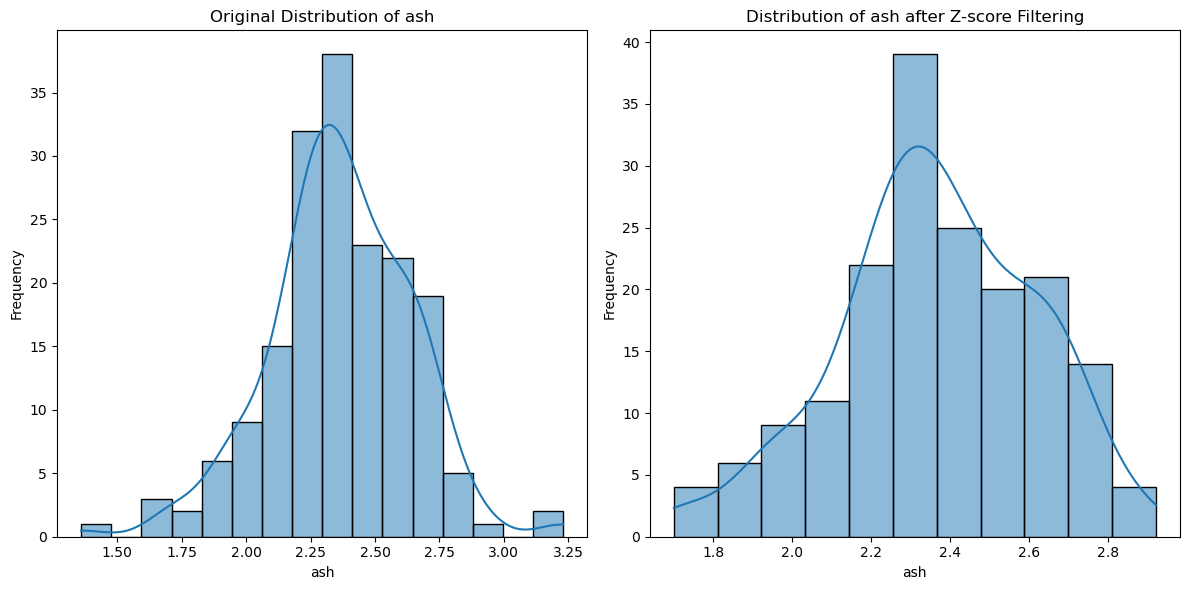

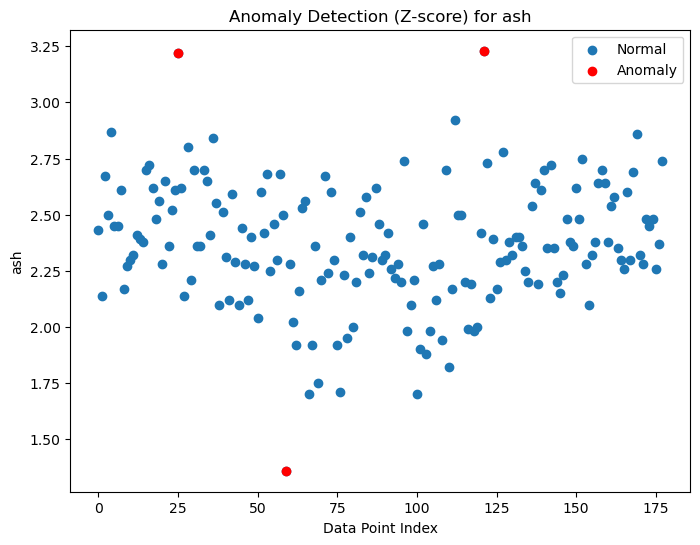

Anomalies found in 'alcalinity_of_ash': 1
    alcalinity_of_ash  z_score_alcalinity_of_ash
73               30.0                   3.300853


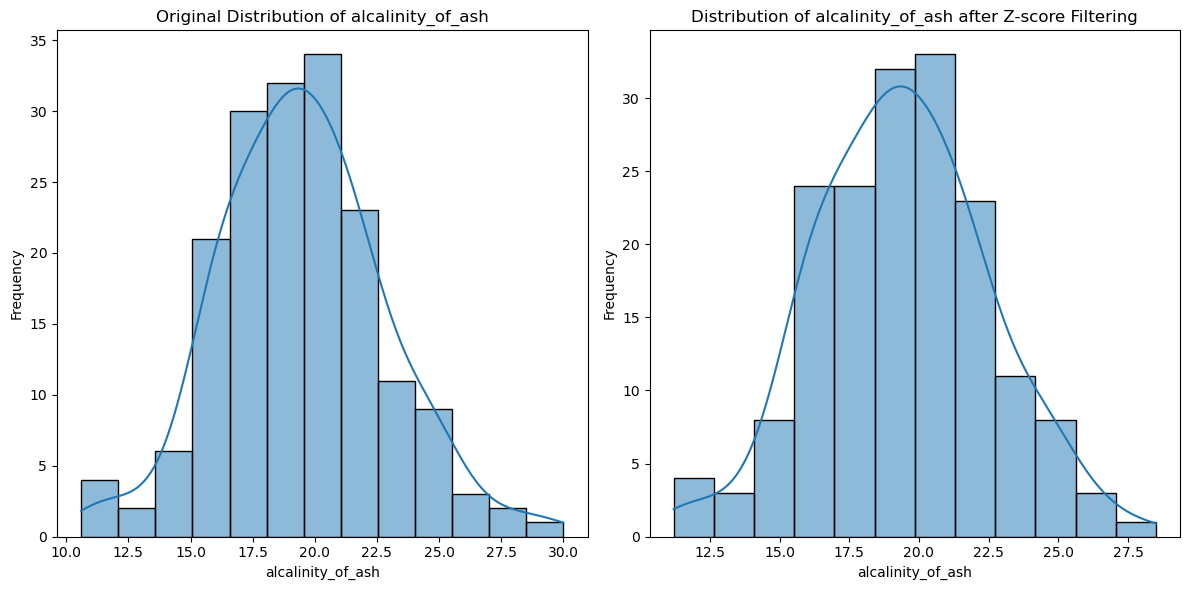

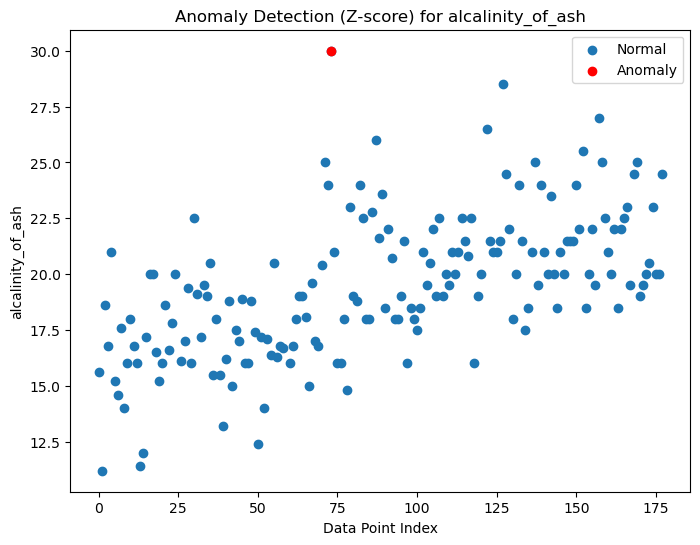

Anomalies found in 'hue': 1
      hue  z_score_hue
115  1.71     3.308821


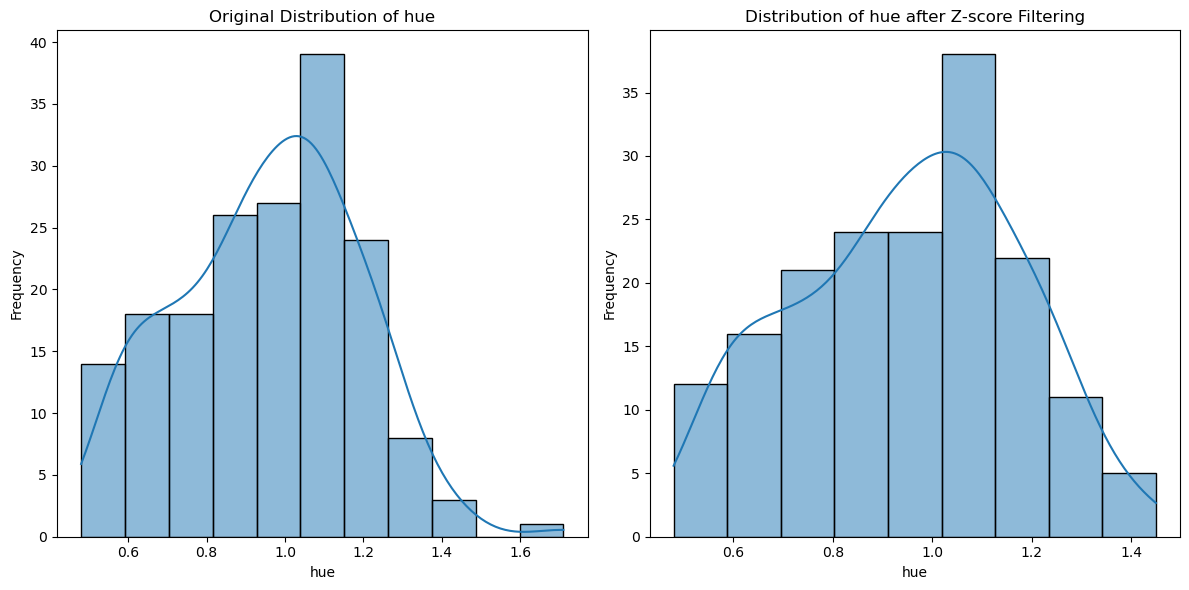

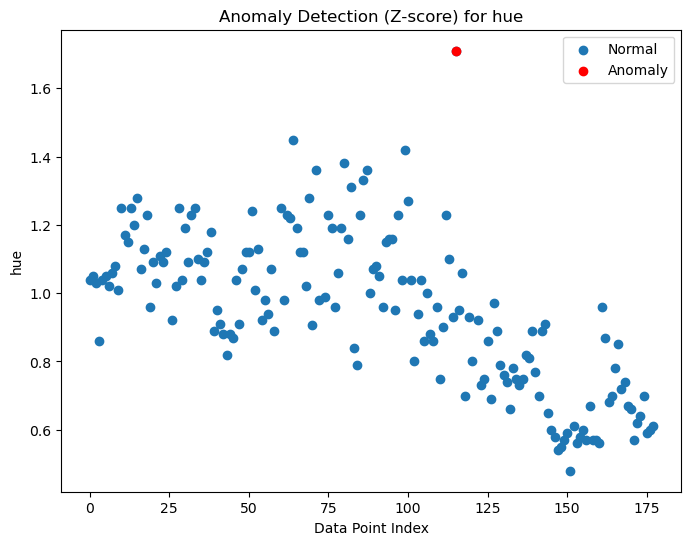

In [40]:
dataset_zscore = df.copy()

for col in symetrical_cols:
  if col in dataset_zscore.columns:
    # Calculate Z-scores
    dataset_zscore['z_score_' + col] = stats.zscore(dataset_zscore[col])

    # Anomaly threshold
    zscore_threshold = 3
    anomalies = dataset_zscore[(dataset_zscore['z_score_' + col].abs() > zscore_threshold)]

    print(f"Anomalies found in '{col}': {len(anomalies)}")
    print(anomalies[[col, 'z_score_' + col]])

    # Visualize the distribution before and after removing anomalies
    plt.figure(figsize=(12, 6))

    # Original distribution
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Original Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Distribution after removing anomalies
    plt.subplot(1, 2, 2)
    sns.histplot(dataset_zscore[dataset_zscore['z_score_' + col].abs() <= zscore_threshold][col], kde=True)
    plt.title(f'Distribution of {col} after Z-score Filtering')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

    # Scatter plot to highlight anomalies
    plt.figure(figsize=(8, 6))
    plt.scatter(dataset_zscore.index, dataset_zscore[col], label='Normal')
    plt.scatter(anomalies.index, anomalies[col], color='red', label='Anomaly')
    plt.title(f'Anomaly Detection (Z-score) for {col}')
    plt.xlabel('Data Point Index')
    plt.ylabel(col)
    plt.legend()
    plt.show()

    # Remove anomalies from the copied dataset
    dataset_zscore = dataset_zscore[dataset_zscore['z_score_' + col].abs() <= zscore_threshold].drop(columns=['z_score_' + col])
  else:
    print(f"Column '{col}' not found in the dataset.")

## Isolation Forest

In [41]:
isolation_forest_cols = [
    column for column in numeric_feature_columns
    if column not in symetrical_cols
]
print(isolation_forest_cols)

['malic_acid', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'od280/od315_of_diluted_wines', 'proline']


Anomalías totales detectadas: 9


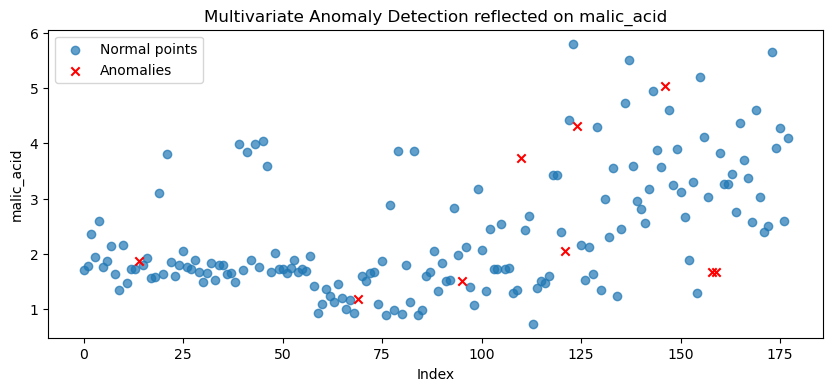

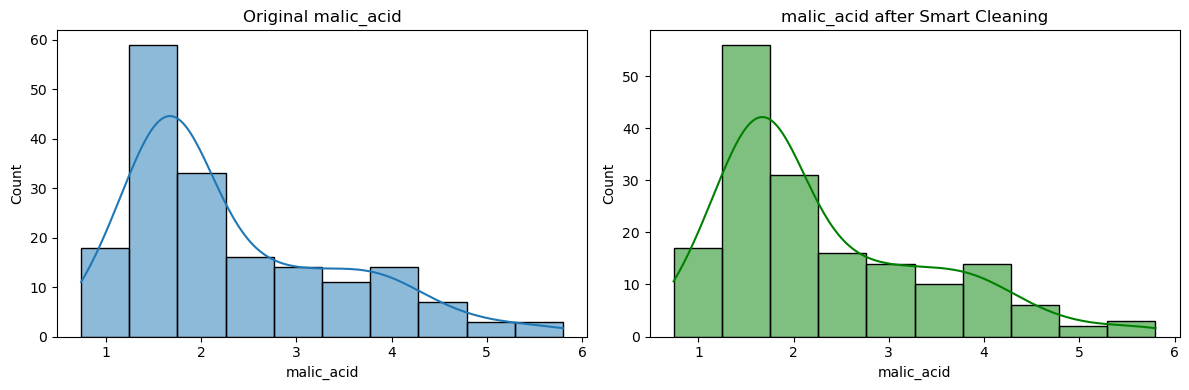

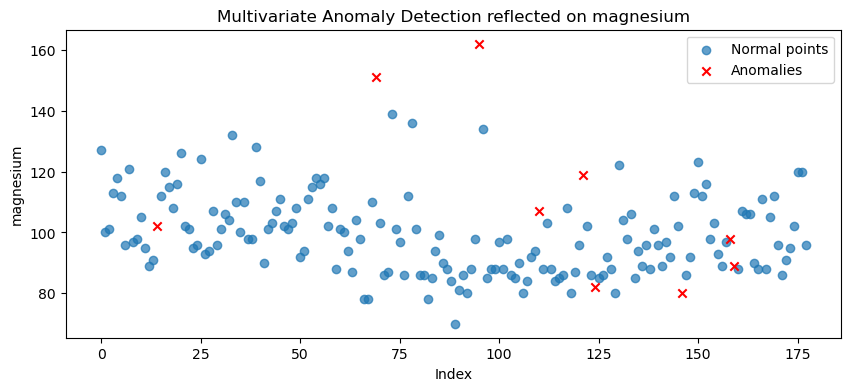

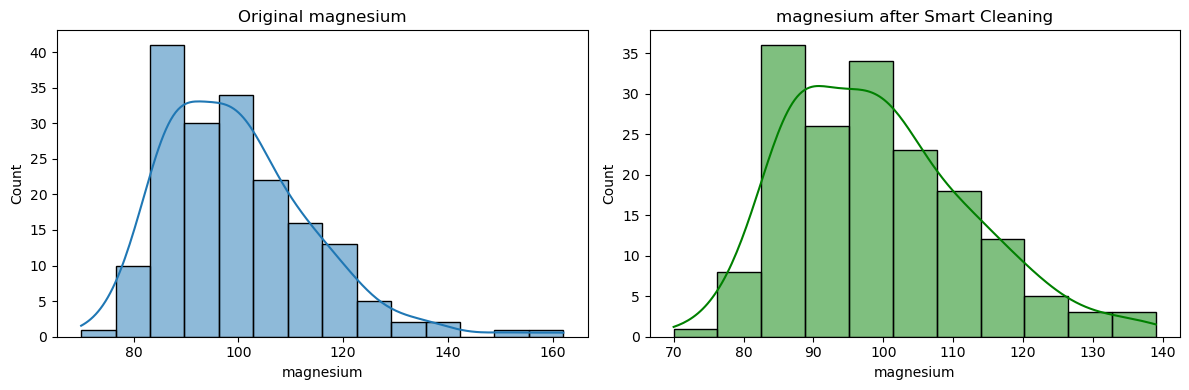

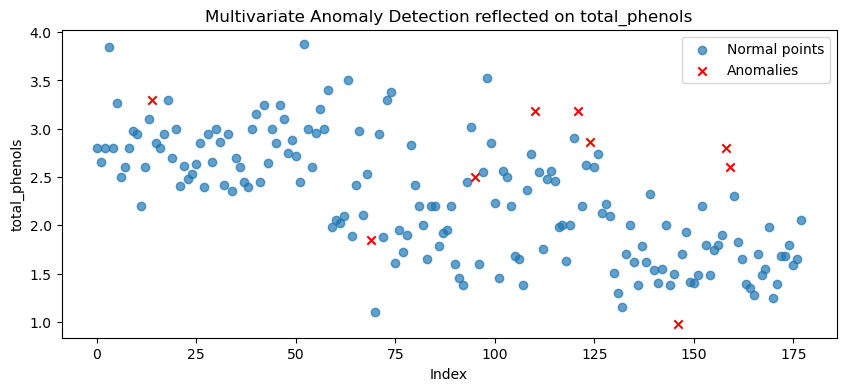

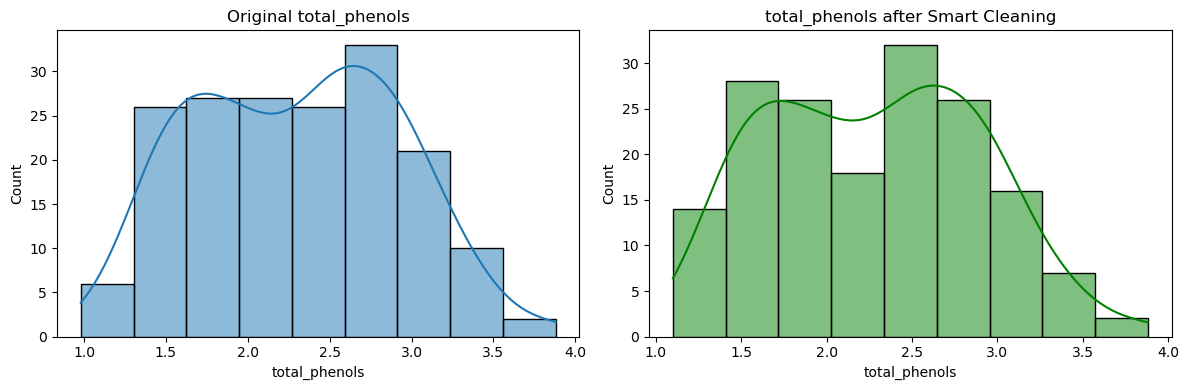

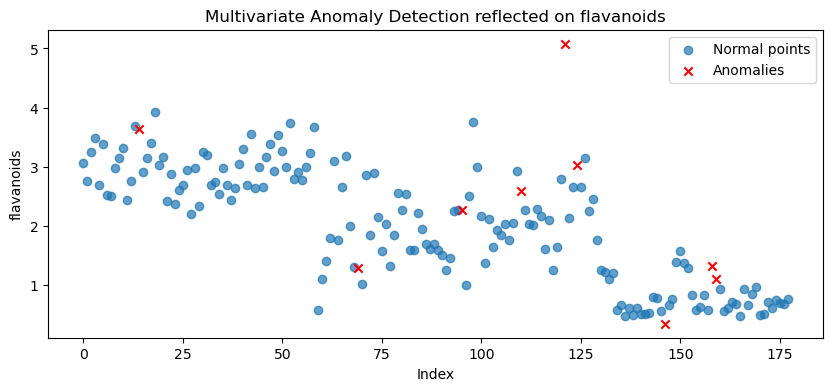

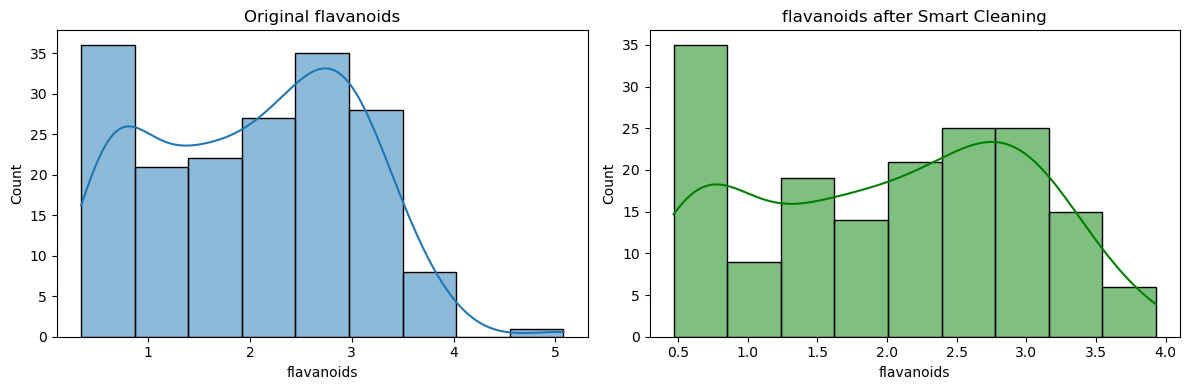

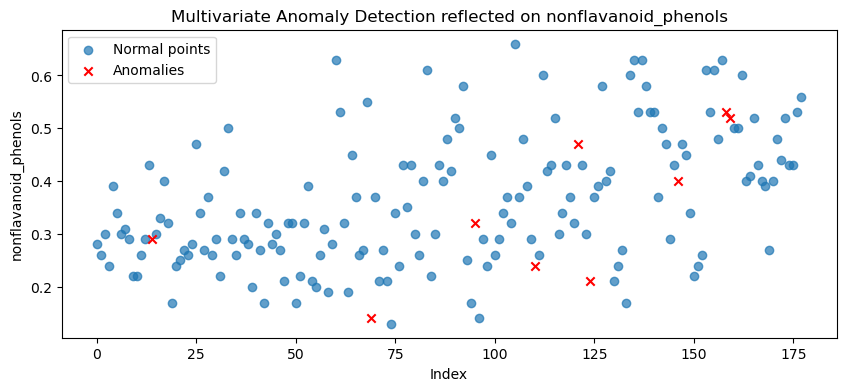

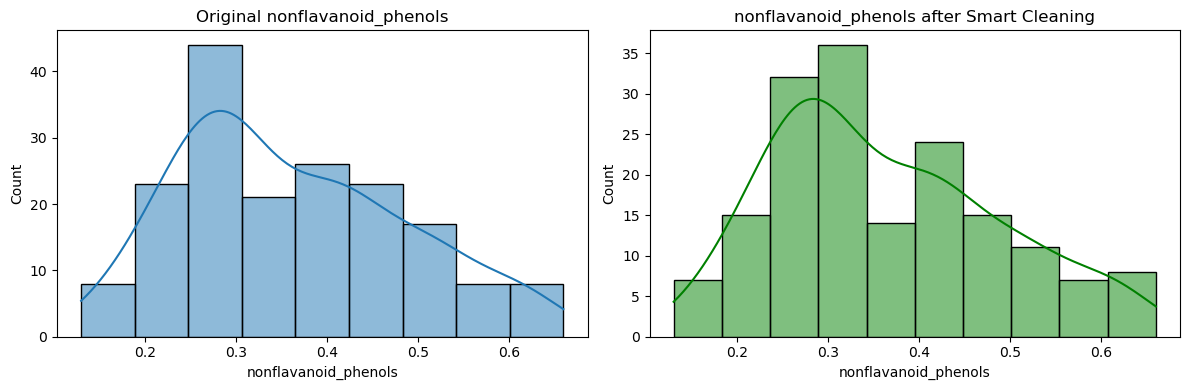

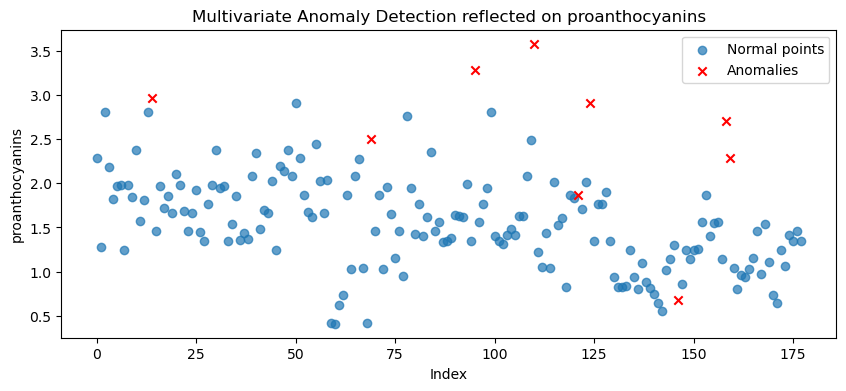

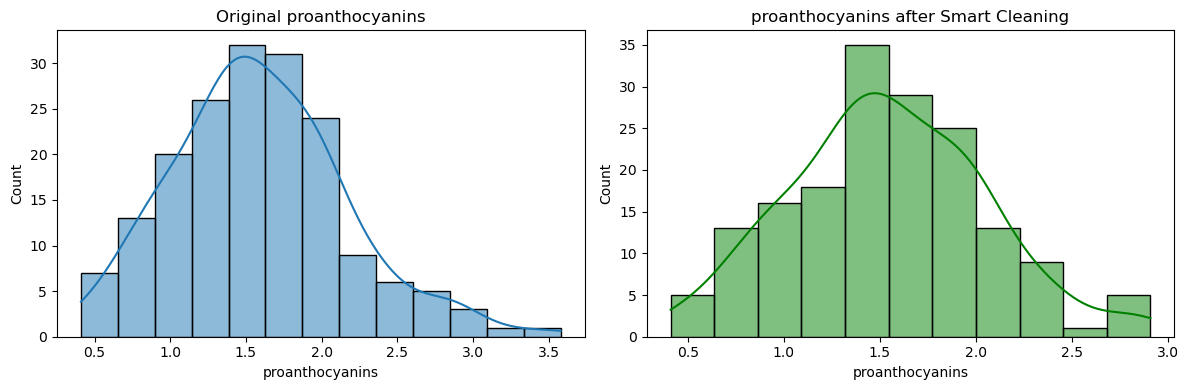

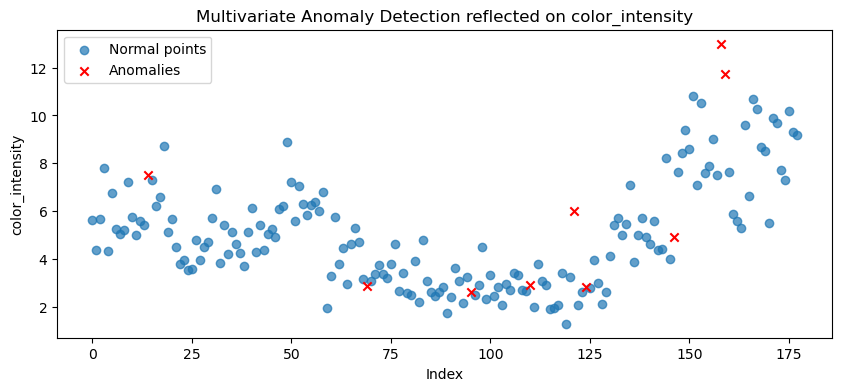

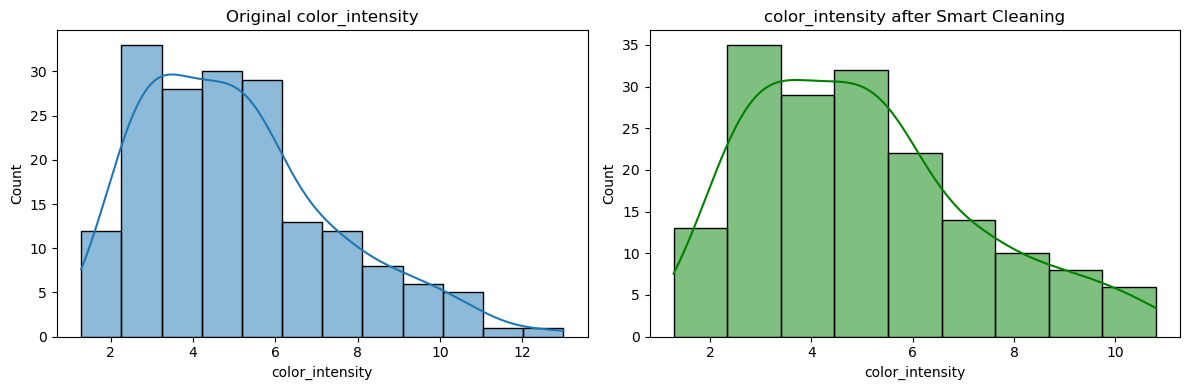

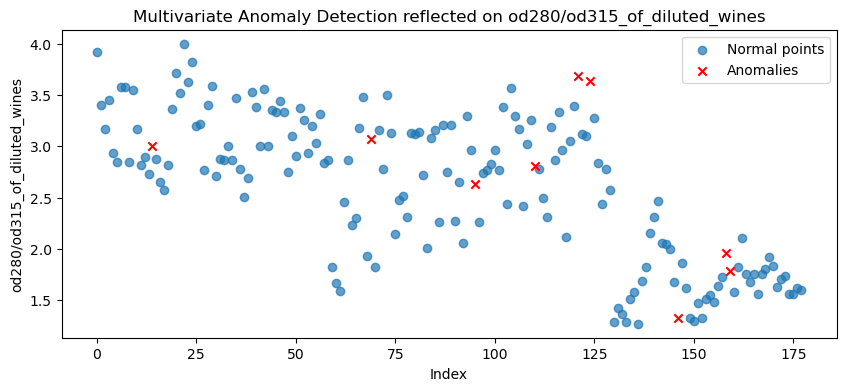

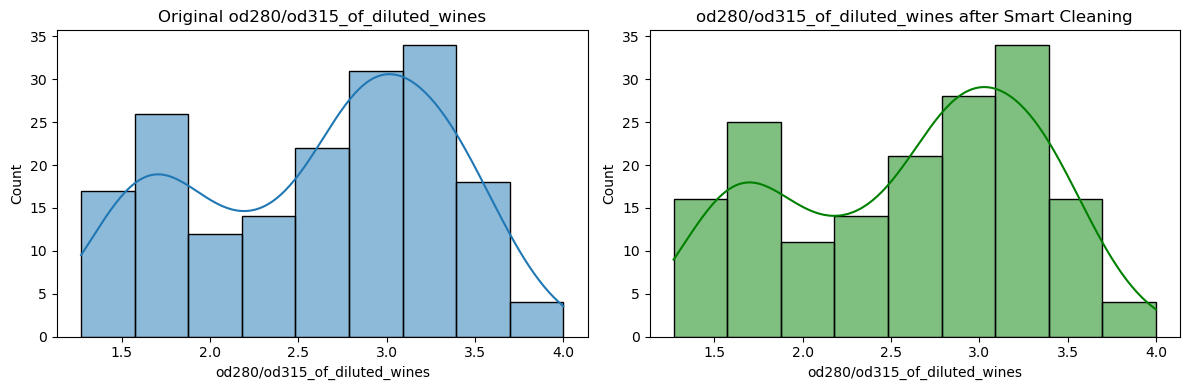

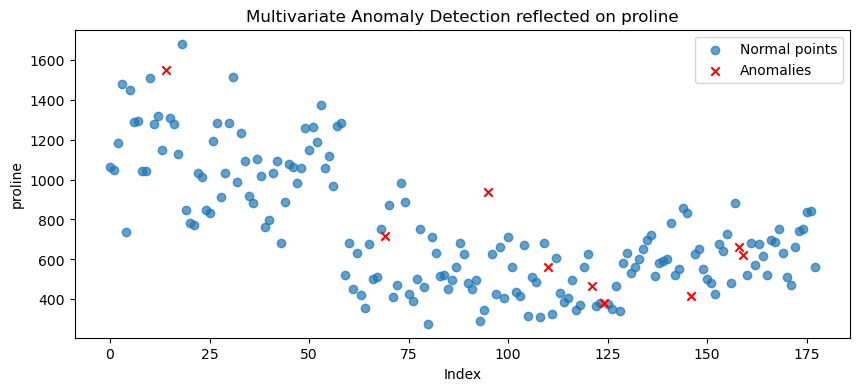

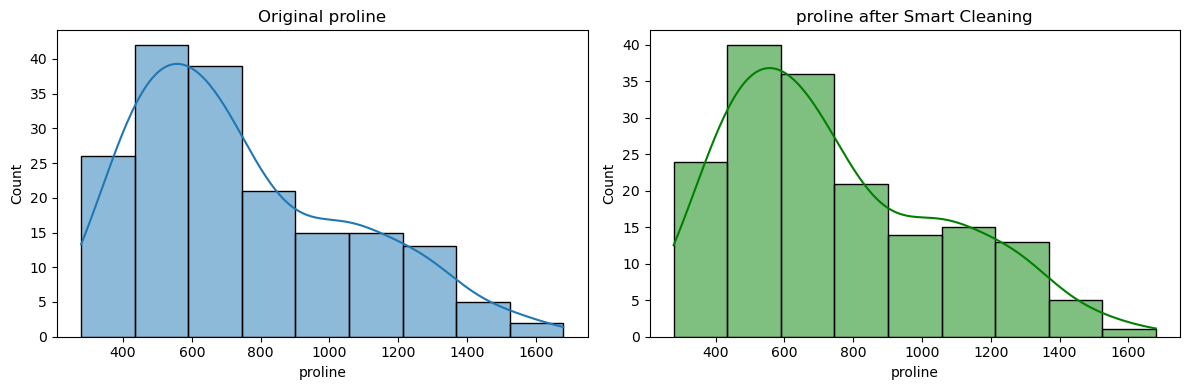

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Seleccionar todas las columnas que quieres usar para el análisis
features = [col for col in isolation_forest_cols if col in dataset_isolated_forest.columns]
X_data = dataset_isolated_forest[features].values

# Optional pero recomendado: Escalar los datos para un comportamiento óptimo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)

# 2. Entrenar IF multidimensional con una contaminación controlada (ej. 5%)
# Si pones 0.05, le dices explícitamente que esperas que solo el 5% de tus vinos sean anomalías reales.
contamination_rate = 0.05 
model = IsolationForest(contamination=contamination_rate, random_state=42)
model.fit(X_scaled)

# 3. Guardar las predicciones globales en el dataset
dataset_isolated_forest['is_anomaly_IF'] = model.predict(X_scaled)

# 4. Crear el dataset limpio libre de anomalías multivariables
datase_isolation_forest = dataset_isolated_forest[dataset_isolated_forest['is_anomaly_IF'] == 1].copy()

print(f"Anomalías totales detectadas: {(dataset_isolated_forest['is_anomaly_IF'] == -1).sum()}")

# ==========================================
# 5. Visualizar los resultados para cada columna
# ==========================================
for col in features:
    # Graficar dispersión de anomalías individuales basadas en la decisión GLOBAL
    plt.figure(figsize=(10, 4))
    # Puntos normales
    plt.scatter(dataset_isolated_forest.index[dataset_isolated_forest['is_anomaly_IF'] == 1], 
                dataset_isolated_forest[col][dataset_isolated_forest['is_anomaly_IF'] == 1], 
                label='Normal points', alpha=0.7)
    # Puntos anómalos (Corrección aquí: .index y marker='x')
    plt.scatter(dataset_isolated_forest.index[dataset_isolated_forest['is_anomaly_IF'] == -1], 
                dataset_isolated_forest[col][dataset_isolated_forest['is_anomaly_IF'] == -1], 
                color='red', label='Anomalies', marker='x')
    
    plt.title(f'Multivariate Anomaly Detection reflected on {col}')
    plt.xlabel('Index')
    plt.ylabel(col)
    plt.legend()
    plt.show()


    # Histogramas Comparativos
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(dataset_isolated_forest[col], kde=True)
    plt.title(f'Original {col}')
    
    plt.subplot(1, 2, 2)
    sns.histplot(datase_isolation_forest[col], kde=True, color='green')
    plt.title(f'{col} after Smart Cleaning')
    plt.tight_layout()
    plt.show()
    print("\n" + "="*50 + "\n")

## Data Filtrada

In [44]:
# Dataset final libre de anomalías detectadas por Z-score e Isolation Forest
clean_indices = dataset_zscore.index.intersection(datase_isolation_forest.index)
dataset_clean = df.loc[clean_indices].copy()

print(f'Dimensiones originales: {df.shape}')
print(f'Dimensiones tras Z-score: {dataset_zscore.shape}')
print(f'Dimensiones tras Isolation Forest: {datase_isolation_forest.shape}')
print(f'Dimensiones finales limpias: {dataset_clean.shape}')

dataset_clean.head()

Dimensiones originales: (178, 14)
Dimensiones tras Z-score: (173, 14)
Dimensiones tras Isolation Forest: (169, 24)
Dimensiones finales limpias: (165, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


# EDA

## Correlation Matrix

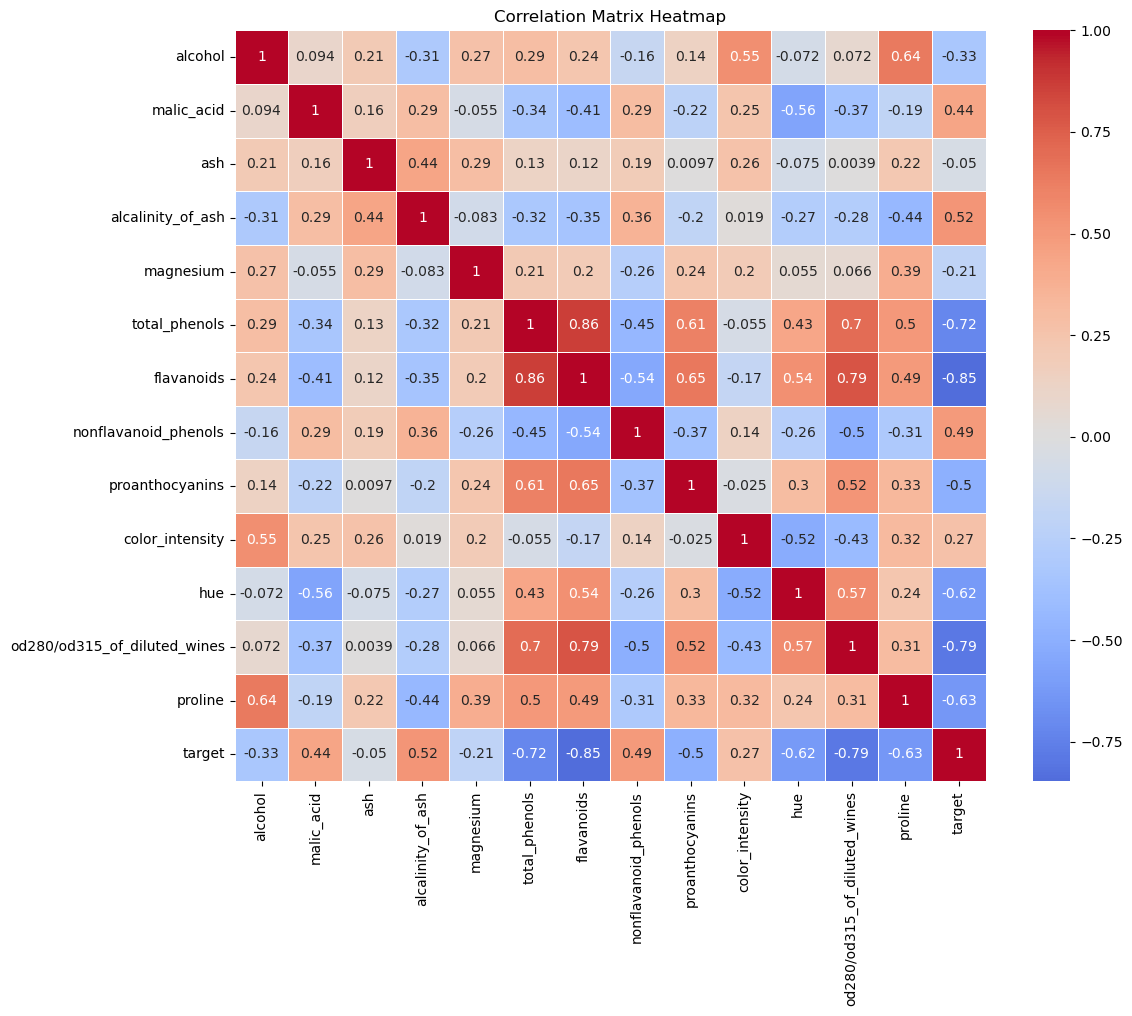

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

# Anova

## ANOVA por variable

In [52]:
# Trabajar sobre una copia para no modificar el dataset filtrado original
dataset_anova = dataset_clean.copy()
dataset_anova.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [53]:
from scipy.stats import f_oneway
import pandas as pd

anova_results = []
target_groups = sorted(dataset_anova['target'].unique())

for col in numeric_feature_columns:
    groups = [
        dataset_anova.loc[dataset_anova['target'] == target_value, col].dropna()
        for target_value in target_groups
    ]

    f_stat, p_value = f_oneway(*groups)
    anova_results.append({
        'feature': col,
        'f_stat': f_stat,
        'p_value': p_value,
    })

anova_results_df = pd.DataFrame(anova_results).sort_values('p_value')
anova_results_df

,feature,f_stat,p_value
6,flavanoids,299.488611,3.798498e-55
12,proline,217.998844,1.143026e-46
11,od280/od315_of_diluted_wines,187.421436,7.130069e-43
0,alcohol,127.212010,6.142124e-34
9,color_intensity,117.590215,2.835966e-32
5,total_phenols,107.840632,1.673230e-30
10,hue,101.067848,3.223982e-29
8,proanthocyanins,45.848454,1.664129e-16
3,alcalinity_of_ash,42.637563,1.327704e-15
1,malic_acid,39.035549,1.456082e-14


# PCA

## Aplicacion de PCA

Explained variance ratio: [0.38600073 0.20347806]
Total explained variance: 0.5894787915781673


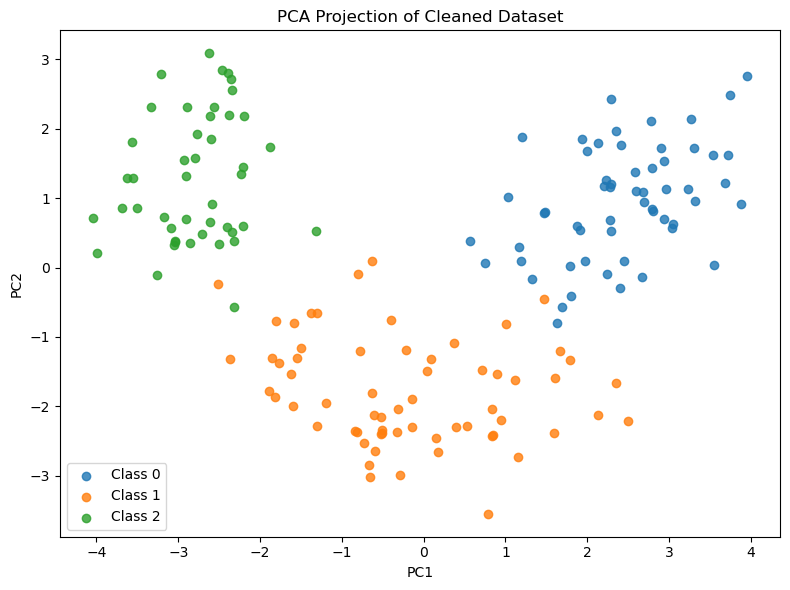

,PC1,PC2,target
0,3.533702,1.619613,0
1,2.399362,-0.300948,0
2,2.690094,0.945353,0
3,3.956057,2.753603,0
4,1.034055,1.009780,0


In [54]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

pca_data = dataset_clean[numeric_feature_columns].copy()
scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_data)

pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(pca_scaled)

pca_df = pd.DataFrame(
    pca_components,
    columns=['PC1', 'PC2'],
    index=dataset_clean.index
)
pca_df['target'] = dataset_clean['target'].values

print('Explained variance ratio:', pca.explained_variance_ratio_)
print('Total explained variance:', pca.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 6))
for target_value in sorted(pca_df['target'].unique()):
    subset = pca_df[pca_df['target'] == target_value]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Class {int(target_value)}', alpha=0.8)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection of Cleaned Dataset')
plt.legend()
plt.tight_layout()
plt.show()

pca_df.head()

# Pair of Distribution

## Create a graph that shows how each variable is distributed with respect to all others

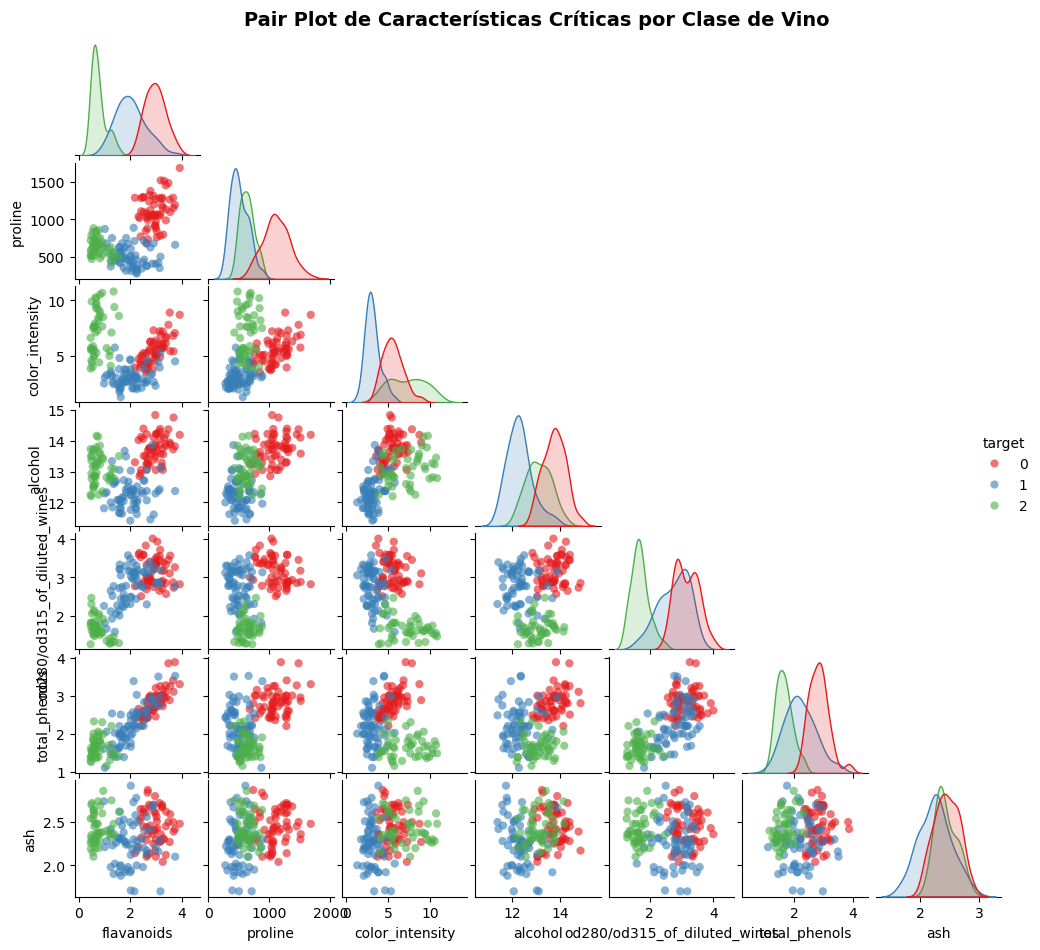

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Seleccionamos solo el "Dream Team" de tus variables según ANOVA
# Flavanoids y Proline (las mejores), Color Intensity (bimodal clave) y Alcohol
top_features = ['flavanoids', 'proline', 'color_intensity', 'alcohol', 'od280/od315_of_diluted_wines', 'total_phenols', 'ash']

# 2. Preparamos los datos igual que antes pero solo con el Top
pairplot_data = dataset_clean[top_features].copy()
pairplot_data['target'] = dataset_clean['target'].values

# 3. Construimos el pairplot estilizado
g = sns.pairplot(
    pairplot_data,
    vars=top_features,
    hue='target',
    palette='Set1',        # Paleta con colores más vivos y distinguibles
    diag_kind='kde',       # Cambiamos a curvas de densidad suaves
    corner=True,           # Mantenemos tu excelente idea del corte diagonal
    height=3.0,            # Ajustamos el tamaño individual de cada sub-gráfico
    aspect=1.2,
    plot_kws={
        'alpha': 0.6,      # Un toque más de transparencia para ver solapamientos
        's': 35,           # Puntos ligeramente más grandes para que resalten
        'edgecolor': 'none' # Eliminamos el borde blanco de los puntos para limpiar la vista
    },
    diag_kws={
        'fill': True,      # Rellenamos el fondo de las curvas de densidad
        'alpha': 0.2       # Opacidad muy suave para el relleno de la diagonal
    }
)

# 4. Ajustamos el tamaño global (ahora mucho más compacto y nítido)
g.fig.set_size_inches(10, 9)
plt.suptitle('Pair Plot de Características Críticas por Clase de Vino', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## Observaciones

- **Selección de Variables (ANOVA y Matriz de Correlación):** La prueba ANOVA y la Matriz de Correlación coinciden en que flavanoids y proline son los predictores químicos más potentes para discriminar las clases de vino. Por el contrario, ash demostró un impacto estadístico nulo (correlación de $-0.05$ y F-score mínimo), por lo que se recomienda su eliminación.
- **Redundancia (Matriz de Correlación y Pairplot):** Existe una alta multicolinealidad entre compuestos fenólicos (total_phenols vs flavanoids con $0.86$). El Pairplot refleja visualmente esta relación lineal perfecta, sugiriendo eliminar total_phenols si se van a utilizar modelos lineales para evitar redundancia.
- **Estrategia de Modelado (PCA y Pairplot):** La proyección bidimensional del PCA y las distribuciones del Pairplot demuestran de forma contundente que las tres clases de vino se agrupan en clusters densos con un solapamiento mínimo.